Dataset: The E13 mouse embryo spatial ATAC-RNA-seq dataset by Zhang et al ([here](https://zenodo.org/))

In [3]:
import os
import sys
adata_input_path = 'spATAC/ME/Raw.h5ad'
pretrain_input_path = 'pretrained/mouse_embryo.h5ad'
adata_output_path = './ME13_out'

In [4]:
import SPEED
import scanpy as sc

/home/lifesci/wangshuyan/miniconda3/envs/pytorch/lib/python3.7/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [5]:
adata = sc.read(adata_input_path)
adata_peak = sc.read(pretrain_input_path)

In [6]:
adata,adata_sc = SPEED.process(adata,adata_peak)

In [7]:
speed = SPEED.SPEED(adata,image=None,k_degree=5, is_spatial=True, adata_sc=adata_sc)

matrix ready...
use 0-1 matrix...
cell_features ready...
peak features ready...


In [8]:
speed.setup_data(num_workers=4)

split ready...
labels ready...
peak embedding is given
dataset ready...


In [9]:
speed.build_model(emb_features=32)

In [ ]:
speed.train(lr=1e-5, device='cpu')

In [12]:
import torch
torch.save(speed.model.state_dict(), f'ME13_out/model_cpu.pth')

In [13]:
adata = speed.get_embedding(adata)

get cell/spot embedding...


100%|██████████| 5/5 [00:01<00:00,  3.84it/s]


get peak embedding...


100%|██████████| 5/5 [00:01<00:00,  3.38it/s]


get spatial embedding...


In [14]:
adata.X = speed.get_denoise_result()

In [15]:
plot = ['chr18:65938870-65939370','chr11:98329370-98329870','chr5:77114908-77115408','chr17:34039380-34039880']

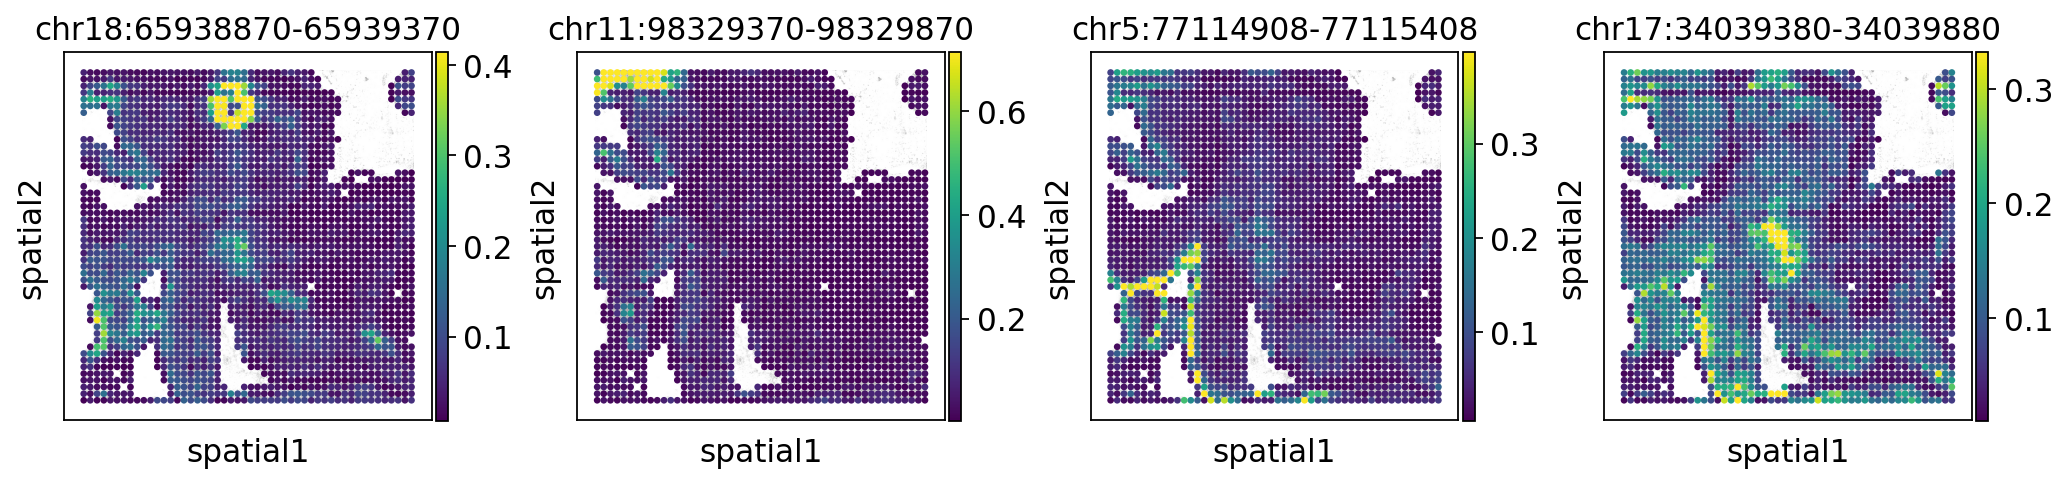

In [16]:
sc.set_figure_params(figsize=(3,3))
sc.pl.spatial(adata,color=plot,basis='spatial',ncols=4,vmax='p99')

In [20]:
adata.write(f'simulation_out/adata_speed.h5ad')